# CNN (Convolutional Neural Network)




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

import csv
import glob
import os

from utils import *
from models import *


I0000 00:00:1780511136.536194    1549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780511136.689685    1549 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
autoencoder = Autoencoder()

autoencoder.set_coef("coeficientes_encoder.csv",'encoder')
autoencoder.set_coef("coeficientes_decoder.csv",'decoder')

Leyendo coeficientes desde: coeficientes_encoder.csv...
 [+] Coeficientes cargados con éxito en la capa: CONV1_16
 [+] Coeficientes cargados con éxito en la capa: CONV2_32
 [+] Coeficientes cargados con éxito en la capa: CONV3_64
 [+] Coeficientes cargados con éxito en la capa: CONV4_128

Proceso finalizado. Se actualizaron 4 capas.
Leyendo coeficientes desde: coeficientes_decoder.csv...
 [+] Coeficientes cargados con éxito en la capa: DECONV1
 [+] Coeficientes cargados con éxito en la capa: DECONV2
 [+] Coeficientes cargados con éxito en la capa: DECONV3
 [+] Coeficientes cargados con éxito en la capa: DECONV4

Proceso finalizado. Se actualizaron 4 capas.


In [3]:
## Levanto el dataset (unicamente los datos de acelerometro)
data = extraer_datos_csv(path='outputs_FallAI_Dataset', file = 'Event_FallAIIDDataSet_*.txt', sensors= ['AccX','AccY','AccZ'])
data.shape


## Extraigo los Tags del dataset

carpeta = 'outputs_FallAI_Dataset'
patron_archivos = os.path.join(carpeta, 'Event_FallAIIDDataSet_*.txt')

# glob.glob devuelve una lista con las rutas de todos los archivos que coincidan
lista_archivos = glob.glob(patron_archivos)

tags = []

for archivo in lista_archivos:
   
    with open(archivo, 'r') as file:
        encabezado = [next(file).strip() for _ in range(5)]  
        for e in encabezado:
            if "TYPE" not in e:
                continue

            if "NOT FALL" in e :
                tags.append(0)
            elif "FALL" in e:
                tags.append(1)
            else:
                print(f"No se dectecto el TAG del dato en el archivo: {archivo}. ")
                


print(f"El shape de data es: {data.shape}")
print(f"El shape de tags es: {len(tags)}")


El shape de data es: (2515, 520, 3)
El shape de tags es: 2515


In [4]:
escalador = dataScaler() ## Fitea los datos y guarda sus coef.

datos_normalizados = escalador.escalar_datos(data)

# Agrega la dimension para coincidir con el input
datos_entrenamiento = np.expand_dims(datos_normalizados, axis=-1)

print(f"Shape datos_entrenamiento {datos_entrenamiento.shape}")

# obtengo datos de prueba y de entrenamiento
data_train, data_test, y_train, y_test = train_test_split(datos_entrenamiento,tags, test_size=0.2, random_state=21)

print(f"Shape data_train: {data_train.shape}")
print(f"Shape data_test: {data_test.shape}")
print(f"Shape y_train: {len(y_train)}")
print(f"Shape y_test: {len(y_test)}")

Shape datos_entrenamiento (2515, 520, 3, 1)
Shape data_train: (2012, 520, 3, 1)
Shape data_test: (503, 520, 3, 1)
Shape y_train: 2012
Shape y_test: 503


In [5]:
neuralnetwork = NN()

/home/guido/miniconda3/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
## Enlazo el encoder con la red neuronal

red_cnn_completa = tf.keras.Sequential([
    autoencoder.encoder, # Desacoplo el decoder
    neuralnetwork.modelNN
])

red_cnn_completa.compile(
    optimizer='adam',
    loss='binary_crossentropy', 
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall')]
)

autoencoder.encoder.summary()
neuralnetwork.summary()
red_cnn_completa.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CONV1_16 (Conv2D)               │ (None, 518, 1, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 259, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV2_32 (Conv2D)               │ (None, 257, 1, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 129, 1, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV3_64 (Conv2D)               │ (None, 127, 1, 64)     │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV4_128 (Conv2D)              │ (None, 62, 1, 128)     │        24,704 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,640 (127.50 KB)

 Trainable params: 32,640 (127.50 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 62, 1, 128)     │        32,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 1)              │        79,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,059 (437.73 KB)

 Trainable params: 112,059 (437.73 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
## Entrenamiento de la red neuronal.

## Importante, la red debe entrenarse con el encoder acoplado.

y_train = np.array(y_train)
y_test = np.array(y_test)

historial = red_cnn_completa.fit(data_train, y_train,
                    epochs=120,
                    validation_data=(data_test, y_test))

Epoch 1/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8072 - loss: 0.5849 - recall: 0.1201 - val_accuracy: 0.9145 - val_loss: 0.3899 - val_recall: 0.5667
Epoch 2/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9289 - loss: 0.3672 - recall: 0.7182 - val_accuracy: 0.9344 - val_loss: 0.3247 - val_recall: 0.8556
Epoch 3/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9404 - loss: 0.3051 - recall: 0.8106 - val_accuracy: 0.9284 - val_loss: 0.2646 - val_recall: 0.7667
Epoch 4/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9488 - loss: 0.2316 - recall: 0.8707 - val_accuracy: 0.9404 - val_loss: 0.2219 - val_recall: 0.8222
Epoch 5/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9642 - loss: 0.1799 - recall: 0.9169 - val_accuracy: 0.9463 - val_loss: 0.1989 - val_recall: 0.8444
Epoch 6/120
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9677 - loss: 0.1593 - recall: 0.9238 - val_accuracy: 0.9503 - val_loss: 0.1991 - val_recall: 0.8444
Epoch 7/1

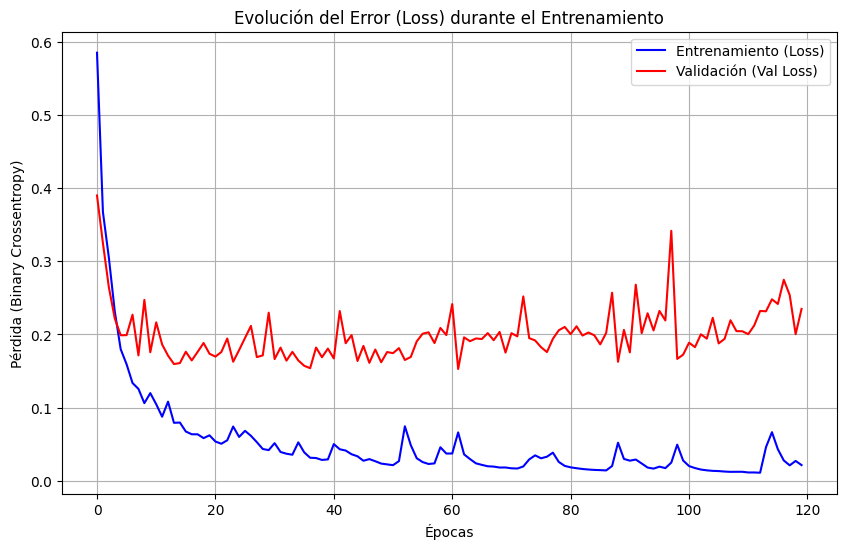

In [8]:
loss_entrenamiento = historial.history['loss']
loss_validacion = historial.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(loss_entrenamiento, label='Entrenamiento (Loss)', color='blue')
plt.plot(loss_validacion, label='Validación (Val Loss)', color='red')

plt.title('Evolución del Error (Loss) durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:

y_pred_prob = red_cnn_completa.predict(data_test)

# El umbral estándar es 0.5 (50%).
y_pred = (y_pred_prob > 0.3).astype(int)

# 3. Imprimimos el reporte completo de clasificación
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_test, y_pred, target_names=["NOT FALL (0)", "FALL (1)"]))

# 4. Calculamos la matriz de confusión
matriz = confusion_matrix(y_test, y_pred)
print("\n=== MATRIZ DE CONFUSIÓN ===")
print("                  Predice NO CAÍDA   Predice CAÍDA")
print(f"Real NO CAÍDA:    {matriz[0][0]}                 {matriz[0][1]}")
print(f"Real CAÍDA:       {matriz[1][0]}                 {matriz[1][1]}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.98      0.96      0.97       413
    FALL (1)       0.83      0.91      0.87        90

    accuracy                           0.95       503
   macro avg       0.90      0.93      0.92       503
weighted avg       0.95      0.95      0.95       503


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    396                 17
Real CAÍDA:       8                 82


# Prueba de datasets cruzados

En el dataset original se tienen muestras de la muñeca, cintura y cuello, tomando en cada caso los datos de acelerometros y otros sensores. Lo que se realiza a continuacion es utilizando los datos de la cintura probar el rendimiento de la red CNN de forma de ver si estos pueden ser aprovechados dentro del dataset de entrenamiento. <br> 
Debido a la diferencia en grados de libertad entre las manos y la cintura es de esperar que no rinda tan bien como con los datos de la muñeca que fue entrenado el modelo. <br>
Otro aspecto de interes a evaluar es utilizar datos de cintura / cuello para pre-entrenar al modelo y luego hacer un fine-tunning con los datos de la muñeca.


In [ ]:
## Levanto el dataset (unicamente los datos de acelerometro)
data_waist = extraer_datos_csv(path='./Datasets/outputs_FallAI_Dataset_Waist', file = 'Event_FallAIIDDataSet_*.txt', sensors= ['AccX','AccY','AccZ'])
data_waist.shape

## Extraigo los Tags del dataset

carpeta = './Datasets/outputs_FallAI_Dataset_Waist'
patron_archivos = os.path.join(carpeta, 'Event_FallAIIDDataSet_*.txt')

# glob.glob devuelve una lista con las rutas de todos los archivos que coincidan
lista_archivos = glob.glob(patron_archivos)

tags_waist = []

for archivo in lista_archivos:
   
    with open(archivo, 'r') as file:
        encabezado = [next(file).strip() for _ in range(5)]  
        for e in encabezado:
            if "TYPE" not in e:
                continue

            if "NOT FALL" in e :
                tags_waist.append(0)
            elif "FALL" in e:
                tags_waist.append(1)
            else:
                print(f"No se dectecto el TAG del dato en el archivo: {archivo}. ")
                


print(f"El shape de data es: {data_waist.shape}")
print(f"El shape de tags es: {len(tags_waist)}")


El shape de data es: (1798, 520, 3)
El shape de tags es: 1798


In [11]:

datos_normalizados_waist = escalador.escalar_datos(data_waist)

# Agrega la dimension para coincidir con el input
datos_evaluacion_waist = np.expand_dims(datos_normalizados_waist, axis=-1)

print(f"Shape datos_entrenamiento {datos_evaluacion_waist.shape}")


Shape datos_entrenamiento (1798, 520, 3, 1)


In [12]:

tags_waist = np.array(tags_waist)
resultados = red_cnn_completa.evaluate(datos_evaluacion_waist, tags_waist, verbose=1)

# Para saber qué valor corresponde a qué métrica:
nombres_metricas = red_cnn_completa.metrics_names
for nombre, valor in zip(nombres_metricas, resultados):
    print(f"{nombre}: {valor:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8293 - loss: 0.9770 - recall: 0.6352
loss: 0.9770
compile_metrics: 0.8293


In [14]:

y_pred_prob = red_cnn_completa.predict(datos_evaluacion_waist)

# El umbral estándar es 0.5 (50%).
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Imprimimos el reporte completo de clasificación
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(tags_waist, y_pred, target_names=["NOT FALL (0)", "FALL (1)"]))

# 4. Calculamos la matriz de confusión
matriz = confusion_matrix(tags_waist, y_pred)
print("\n=== MATRIZ DE CONFUSIÓN ===")
print("                  Predice NO CAÍDA   Predice CAÍDA")
print(f"Real NO CAÍDA:    {matriz[0][0]}                 {matriz[0][1]}")
print(f"Real CAÍDA:       {matriz[1][0]}                 {matriz[1][1]}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

NOT FALL (0)       0.88      0.90      0.89      1332
    FALL (1)       0.68      0.64      0.66       466

    accuracy                           0.83      1798
   macro avg       0.78      0.77      0.77      1798
weighted avg       0.83      0.83      0.83      1798


=== MATRIZ DE CONFUSIÓN ===
                  Predice NO CAÍDA   Predice CAÍDA
Real NO CAÍDA:    1195                 137
Real CAÍDA:       170                 296
